Using: cuda
Morphology: donor=50.0%  interface=21.9%
Parameters: 200,708
Phase 1: Poisson only
     0 | poisson=0.369491
   500 | poisson=0.000011
  1000 | poisson=0.000008
  1500 | poisson=0.000007
  2000 | poisson=0.000006
  2500 | poisson=0.000001

Phase 2: + electron + hole
     0 | p=0.00000 e=17.20415 h=18.80904
   750 | p=0.00000 e=0.00001 h=0.00000
  1500 | p=0.00000 e=0.00000 h=0.00000
  2250 | p=0.00000 e=0.00000 h=0.00000
  3000 | p=0.00000 e=0.00000 h=0.00000
  3750 | p=0.00000 e=0.00000 h=0.00000
  4500 | p=0.00000 e=0.00000 h=0.00000

Phase 3: Full system
      0 | p=0.00000 e=0.00000 h=0.00000 x=0.00500 cons=4.05e-08
   4000 | p=0.00000 e=0.00063 h=0.00003 x=0.00165 cons=4.89e-06
   8000 | p=0.00001 e=0.00086 h=0.00001 x=0.00105 cons=4.23e-06
  12000 | p=0.00001 e=0.00071 h=0.00001 x=0.00064 cons=3.37e-06
  16000 | p=0.00000 e=0.00071 h=0.00001 x=0.00072 cons=3.51e-06

Saved 2D BHJ model.

Jsc   = 0.014460
J_var = 2.99e-06


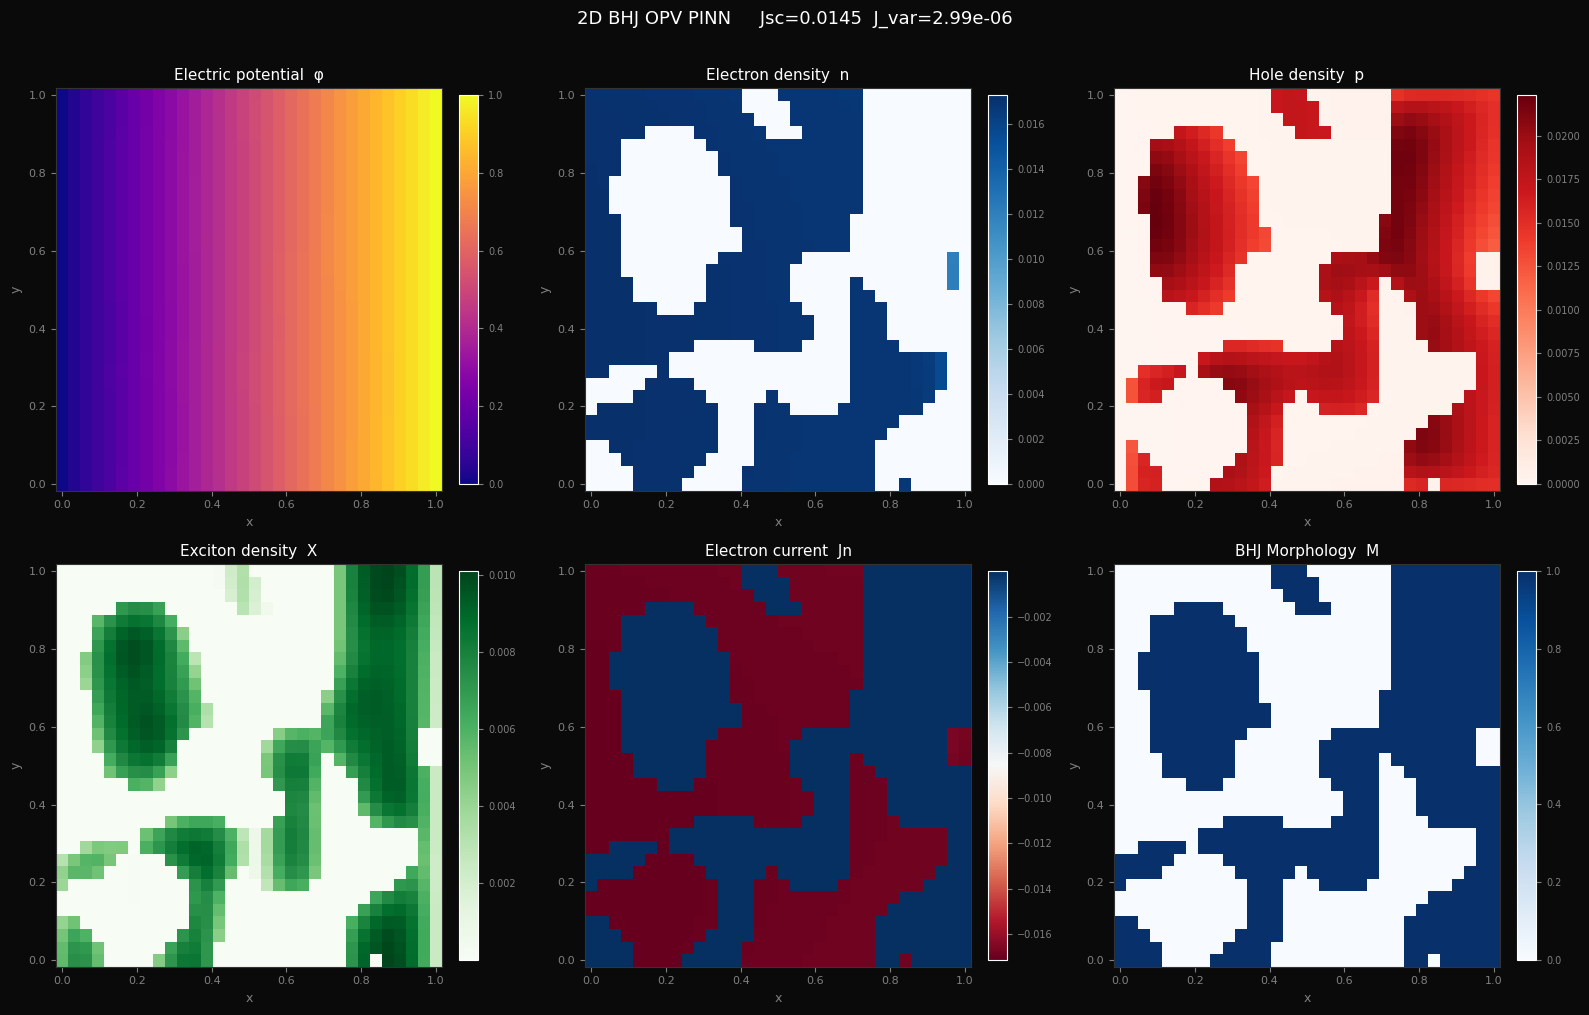

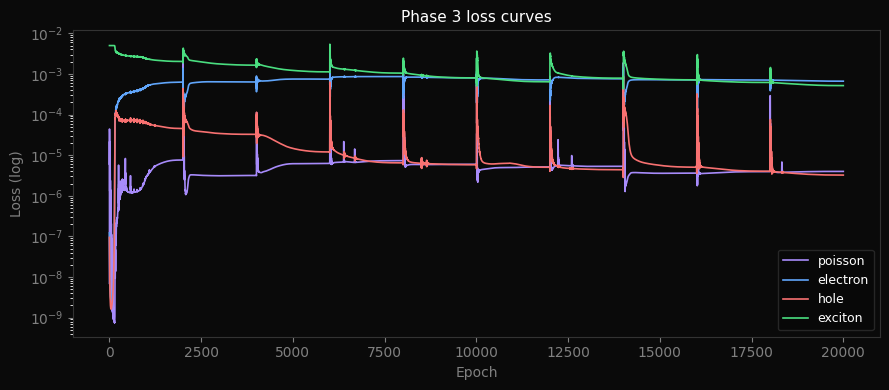

In [ ]:
# ============================================
# IMPORTS
# ============================================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

# ============================================
# CONSTANTS
# ============================================
N_grid = 32      # spatial resolution — start small, scale up later
N_col  = N_grid * N_grid   # total collocation points

q      = 1.0
Vt     = 0.025
mu_n   = 1.0
mu_p   = 1.0
mu_X   = 1.0
k_rec  = 0.1
k_diss = 5.0
G      = 0.1
alpha  = 3.0

# ============================================
# BHJ MORPHOLOGY
# ============================================
np.random.seed(42)
noise     = np.random.randn(N_grid, N_grid)
smoothed  = gaussian_filter(noise, sigma=2)

# Threshold at median — guarantees 50% donor
threshold = np.percentile(smoothed, 50)
M_np      = (smoothed > threshold).astype(float)

print(f"Morphology: donor={M_np.mean():.1%}  "
      f"interface={((np.abs(np.diff(M_np,axis=0)).sum() + np.abs(np.diff(M_np,axis=1)).sum()) / M_np.size):.1%}")

# Flatten to [N²] then [N², 1]
M_flat = torch.tensor(M_np.flatten(), dtype=torch.float32).reshape(-1, 1).to(device)

# ============================================
# GRID — (x, y) collocation points
# x = left→right (electrode direction)
# y = top→bottom (transverse direction)
# ============================================
x_lin   = torch.linspace(0, 1, N_grid)
y_lin   = torch.linspace(0, 1, N_grid)
Xg, Yg  = torch.meshgrid(x_lin, y_lin, indexing='ij')

# Shape: [N², 2]
coords  = torch.stack([Xg, Yg], dim=-1).reshape(-1, 2).to(device)
coords.requires_grad_(True)

# ============================================
# NETWORK — takes (x, y, M) → 3 inputs
# ============================================
def make_net(hidden=128):
    net = nn.Sequential(
        nn.Linear(3, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, 1)
    )
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    return net

class PINN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.phi_net = make_net()
        self.n_net   = make_net()
        self.p_net   = make_net()
        self.X_net   = make_net()

    def forward(self, coords, M):
        # coords: [N², 2]  — (x, y) for each point
        # M:      [N², 1]  — donor=1, acceptor=0
        inp = torch.cat([coords, M], dim=1)   # [N², 3]

        # Hard BC: phi(x=0)=0, phi(x=1)=1
        # phi = x + x*(1-x)*net  satisfies this in 2D too
        # because at x=0: phi=0, at x=1: phi=1 regardless of y
        x = coords[:, 0:1]   # x-coordinate only
        y = coords[:, 1:2]   # y-coordinate only

        phi = x  +  x * (1 - x) * self.phi_net(inp)

        # n: zero at x=1 (anode)
        n = (1 - x) * torch.nn.functional.softplus(self.n_net(inp))

        # p: zero at x=0 (cathode)
        p = x * torch.nn.functional.softplus(self.p_net(inp) + 1.0)

        # X: non-negative
        X = torch.nn.functional.softplus(self.X_net(inp))

        return phi, n, p, X

model = PINN2D().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ============================================
# GRADIENT HELPERS — 2D versions
# ============================================
def grad(f, coords):
    """∂f/∂coords — returns [N², 2] for [∂f/∂x, ∂f/∂y]"""
    return torch.autograd.grad(
        f, coords,
        grad_outputs=torch.ones_like(f),
        create_graph=True,
        retain_graph=True
    )[0]

def laplacian(f, coords):
    """∇²f = ∂²f/∂x² + ∂²f/∂y²"""
    g    = grad(f, coords)          # [N², 2]
    gx   = g[:, 0:1]               # ∂f/∂x
    gy   = g[:, 1:2]               # ∂f/∂y
    gxx  = grad(gx, coords)[:, 0:1]   # ∂²f/∂x²
    gyy  = grad(gy, coords)[:, 1:2]   # ∂²f/∂y²
    return gxx + gyy                # ∇²f

def divergence(Fx, Fy, coords):
    """∇·F = ∂Fx/∂x + ∂Fy/∂y"""
    dFx_dx = grad(Fx, coords)[:, 0:1]
    dFy_dy = grad(Fy, coords)[:, 1:2]
    return dFx_dx + dFy_dy

def fresh_coords():
    """Fresh collocation points with requires_grad."""
    x_lin  = torch.linspace(0, 1, N_grid)
    y_lin  = torch.linspace(0, 1, N_grid)
    Xg, Yg = torch.meshgrid(x_lin, y_lin, indexing='ij')
    c = torch.stack([Xg, Yg], dim=-1).reshape(-1, 2).to(device)
    c.requires_grad_(True)
    return c

# ============================================
# COMPUTE ALL — 2D version
# ============================================
def compute_all(coords, M_flat):
    phi, n, p, X = model(coords, M_flat)

    # Gradients of all fields
    grad_phi = grad(phi, coords)   # [N², 2]
    grad_n   = grad(n,   coords)
    grad_p   = grad(p,   coords)
    grad_X   = grad(X,   coords)

    # Laplacians
    lap_phi = laplacian(phi, coords)   # [N², 1]
    lap_X   = laplacian(X,   coords)

    # Current densities — 2D vectors
    Jn_x = -q * n * mu_n * grad_phi[:, 0:1]  +  q * Vt * mu_n * grad_n[:, 0:1]
    Jn_y = -q * n * mu_n * grad_phi[:, 1:2]  +  q * Vt * mu_n * grad_n[:, 1:2]
    Jp_x = -q * p * mu_p * grad_phi[:, 0:1]  -  q * Vt * mu_p * grad_p[:, 0:1]
    Jp_y = -q * p * mu_p * grad_phi[:, 1:2]  -  q * Vt * mu_p * grad_p[:, 1:2]

    # Divergences
    div_Jn = divergence(Jn_x, Jn_y, coords)
    div_Jp = divergence(Jp_x, Jp_y, coords)

    # Source terms
    R      = k_rec  * n * p
    R_X    = k_rec  * X
    field_mag = torch.norm(grad_phi, dim=1, keepdim=True)
    D_term = k_diss * X * field_mag

    # Generation — in donor only, uniform
    G_field = G * M_flat

    # ============================================
    # PDE LOSSES
    # ============================================

    # Poisson: ∇²φ = q(n - p)
    L_poisson  = torch.mean((lap_phi - q * (n - p))**2)

    # Electron continuity: ∇·Jn - R + D = 0
    L_electron = torch.mean((div_Jn - R + D_term)**2)

    # Hole continuity: -∇·Jp - R + D = 0
    L_hole     = torch.mean((-div_Jp - R + D_term)**2)

    # Exciton transport: Vt·μX·∇²X - D - R_X + G = 0
    L_exciton  = torch.mean((Vt * mu_X * lap_X - D_term - R_X + G_field)**2)

    # Zero-flux BCs for X at y=0 and y=1
    # grad_X[:, 1:2] is ∂X/∂y
    y_coords = coords[:, 1]
    y0_mask  = y_coords < (1.0 / N_grid)
    y1_mask  = y_coords > (1.0 - 1.0 / N_grid)
    L_X_bc   = (torch.mean(grad_X[y0_mask, 1:2]**2) +
                torch.mean(grad_X[y1_mask, 1:2]**2))

    # BC for phi at y boundaries — zero flux ∂φ/∂y = 0
    L_phi_ybc = (torch.mean(grad_phi[y0_mask, 1:2]**2) +
                 torch.mean(grad_phi[y1_mask, 1:2]**2))

    return (L_poisson, L_electron, L_hole, L_exciton,
            L_X_bc, L_phi_ybc, Jn_x, Jp_x)

# ============================================
# TRAINING — curriculum
# ============================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("=" * 55)
print("Phase 1: Poisson only")
print("=" * 55)
for epoch in range(3000):
    optimizer.zero_grad()
    coords  = fresh_coords()
    L_p, *_ = compute_all(coords, M_flat)
    L_p.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if epoch % 500 == 0:
        print(f"  {epoch:4d} | poisson={L_p.item():.6f}")

print("\n" + "=" * 55)
print("Phase 2: + electron + hole")
print("=" * 55)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
for epoch in range(5000):
    optimizer.zero_grad()
    coords = fresh_coords()
    L_p, L_e, L_h, L_x, L_xbc, L_pbc, Jn_x, Jp_x = compute_all(coords, M_flat)
    loss = L_p + L_e + L_h + 5.0*L_pbc
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if epoch % 750 == 0:
        print(f"  {epoch:4d} | p={L_p.item():.5f} "
              f"e={L_e.item():.5f} h={L_h.item():.5f}")

print("\n" + "=" * 55)
print("Phase 3: Full system")
print("=" * 55)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=2000
)
history = {"poisson": [], "electron": [], "hole": [], "exciton": []}

for epoch in range(20000):
    optimizer.zero_grad()
    coords = fresh_coords()
    L_p, L_e, L_h, L_x, L_xbc, L_pbc, Jn_x, Jp_x = compute_all(coords, M_flat)

    # Domain constraints
    phi_v2, n_v2, p_v2, X_v2 = model(coords, M_flat)
    L_n_domain = torch.mean((n_v2 * M_flat)**2)
    L_p_domain = torch.mean((p_v2 * (1 - M_flat))**2)

    # Current conservation
    L_cons = torch.var(Jn_x + Jp_x)

    loss = (
          1.0  * L_p
        + 1.0  * L_e
        + 5.0  * L_h
        + 1.0  * L_x
        + 5.0  * L_xbc
        + 5.0  * L_pbc
        + 10.0 * L_n_domain
        + 10.0 * L_p_domain
        + 50.0 * L_cons
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    history["poisson"].append(L_p.item())
    history["electron"].append(L_e.item())
    history["hole"].append(L_h.item())
    history["exciton"].append(L_x.item())

    if epoch % 4000 == 0:
        print(f"  {epoch:5d} | p={L_p.item():.5f} "
              f"e={L_e.item():.5f} h={L_h.item():.5f} "
              f"x={L_x.item():.5f} cons={L_cons.item():.2e}")

torch.save(model.state_dict(), 'model_2d_bhj.pt')
print("\nSaved 2D BHJ model.")

# ============================================
# VISUALIZATION
# ============================================
model.eval()
coords_vis = fresh_coords()

phi_v, n_v, p_v, X_v = model(coords_vis, M_flat)
grad_phi_v = grad(phi_v, coords_vis)
grad_n_v   = grad(n_v,   coords_vis)
grad_p_v   = grad(p_v,   coords_vis)

Jn_x_v = (-q*n_v*mu_n*grad_phi_v[:,0:1] +
            q*Vt*mu_n*grad_n_v[:,0:1])
Jp_x_v = (-q*p_v*mu_p*grad_phi_v[:,0:1] -
            q*Vt*mu_p*grad_p_v[:,0:1])
Jtot_v  = Jn_x_v + Jp_x_v

def to_grid(t):
    return t.detach().cpu().numpy().reshape(N_grid, N_grid)

phi_np  = to_grid(phi_v)
n_np    = to_grid(n_v)
p_np    = to_grid(p_v)
X_np    = to_grid(X_v)
Jn_np   = to_grid(Jn_x_v)
Jp_np   = to_grid(Jp_x_v)
Jtot_np = to_grid(Jtot_v)

# Jsc — average x-current at right electrode (x=1)
# Right electrode = last column in x direction
Jsc = -float(Jn_x_v.reshape(N_grid, N_grid)[-1, :].mean().detach() +
             Jp_x_v.reshape(N_grid, N_grid)[-1, :].mean().detach())
J_var = float(torch.var(Jtot_v).detach())

print(f"\nJsc   = {Jsc:.6f}")
print(f"J_var = {J_var:.2e}")

x_ax = np.linspace(0, 1, N_grid)
y_ax = np.linspace(0, 1, N_grid)
BG   = '#0a0a0a'
plt.style.use('dark_background')

# --- Figure 1: fields ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor(BG)

field_configs = [
    (phi_np,   'Electric potential  φ', 'plasma'),
    (n_np,     'Electron density  n',   'Blues'),
    (p_np,     'Hole density  p',       'Reds'),
    (X_np,     'Exciton density  X',    'Greens'),
    (Jn_np,    'Electron current  Jn',  'RdBu'),
    (M_np,     'BHJ Morphology  M',     'Blues'),
]

for ax, (field, title, cmap) in zip(axes.flat, field_configs):
    ax.set_facecolor(BG)
    im = ax.pcolormesh(x_ax, y_ax, field.T,
                       cmap=cmap, shading='auto')
    plt.colorbar(im, ax=ax, fraction=0.046,
                 pad=0.04).ax.tick_params(colors='gray', labelsize=7)
    ax.set_title(title, color='white', fontsize=11)
    ax.set_xlabel('x', color='gray', fontsize=9)
    ax.set_ylabel('y', color='gray', fontsize=9)
    ax.tick_params(colors='gray', labelsize=8)
    for s in ax.spines.values(): s.set_edgecolor('#333333')

fig.suptitle(
    f'2D BHJ OPV PINN     Jsc={Jsc:.4f}  J_var={J_var:.2e}',
    color='white', fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('bhj_2d_fields.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

# --- Figure 2: loss curves ---
fig2, ax2 = plt.subplots(figsize=(9, 4))
fig2.patch.set_facecolor(BG)
ax2.set_facecolor(BG)
for key, color in [("poisson",  '#a78bfa'), ("electron", '#60a5fa'),
                   ("hole",     '#f87171'), ("exciton",  '#4ade80')]:
    ax2.semilogy(history[key], linewidth=1.2,
                 color=color, label=key)
ax2.set_title('Phase 3 loss curves', color='white', fontsize=11)
ax2.set_xlabel('Epoch', color='gray')
ax2.set_ylabel('Loss (log)', color='gray')
ax2.legend(fontsize=9, framealpha=0.15, labelcolor='white')
ax2.tick_params(colors='gray')
for s in ax2.spines.values(): s.set_edgecolor('#333333')
plt.tight_layout()
plt.savefig('bhj_2d_losses.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()